In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('creditcard.csv')

print('---- shape and first 5 rows ----')
print('shape:',df.shape)
print('first 5 rows:',df.head())

---- shape and first 5 rows ----
shape: (284807, 31)
first 5 rows:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278

In [ ]:
print('-----data types-----')
print(df.dtypes)

-----data types-----
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


#NULL VALUES

In [ ]:
print('---- Missing Values ----')
print(df.isnull().sum())

---- Missing Values ----
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


#EDA

class distribution

In [ ]:
print('---- class distribution ----')
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True)*100)

---- class distribution ----
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Legit transactions: 284315
Fraud transactions: 492


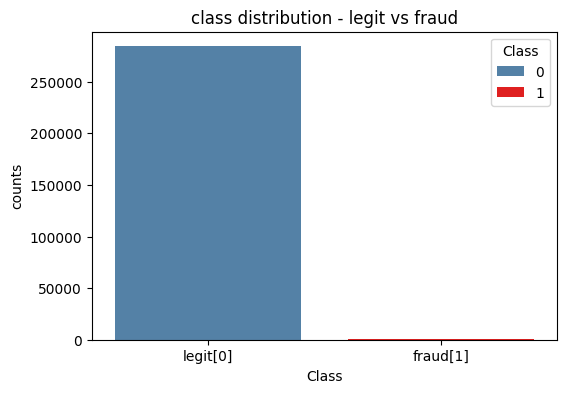

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class',data=df,hue='Class',palette=['steelblue','red'])
plt.title('class distribution - legit vs fraud')
plt.xticks([0,1], ['legit[0]','fraud[1]'])
plt.ylabel('counts')
plt.show

print("Legit transactions:",df[df['Class']==0].shape[0])
print("Fraud transactions:",df[df['Class']==1].shape[0])

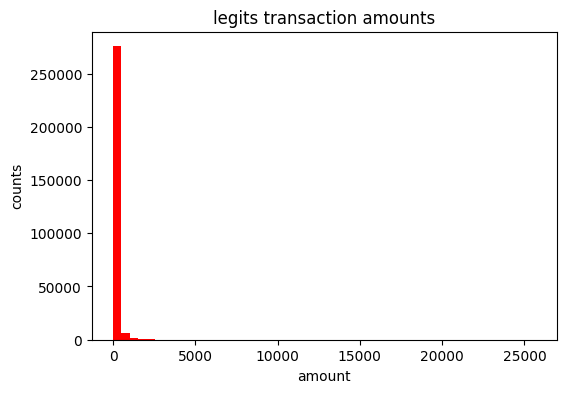

average legit amount: 88.29


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df[df['Class']==0]['Amount'],bins=50,color='red')
plt.title('legits transaction amounts')
plt.xlabel('amount')
plt.ylabel('counts')
plt.show()

print('average legit amount:',round(df[df['Class']==0]['Amount'].mean(),2))

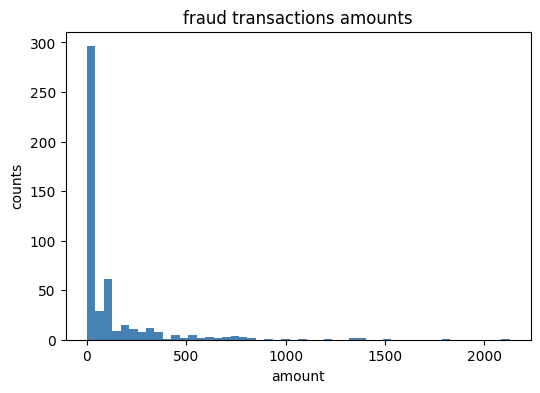

average fraud amount: 122.21


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df[df['Class']==1]['Amount'],bins=50,color='steelblue')
plt.title('fraud transactions amounts')
plt.xlabel('amount')
plt.ylabel('counts')
plt.show()

print('average fraud amount:',round(df[df['Class']==1]['Amount'].mean(),2))

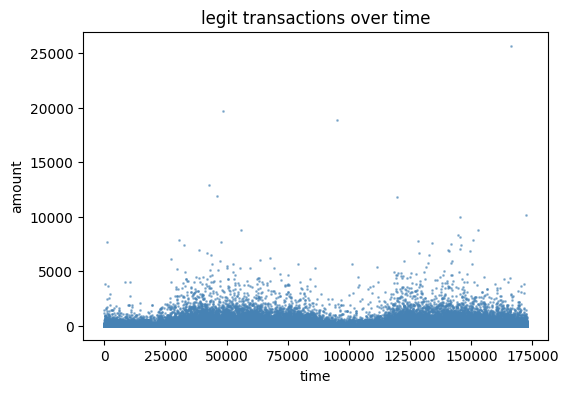

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df[df['Class']==0]['Time'],df[df['Class']==0]['Amount'],alpha=0.5,color='steelblue',s=1)
plt.title('legit transactions over time')
plt.xlabel('time')
plt.ylabel('amount')
plt.show()

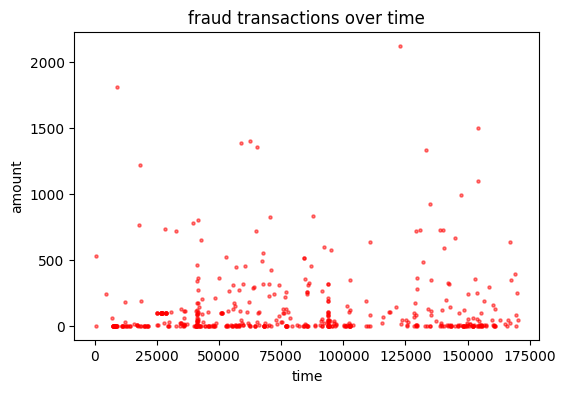

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df[df['Class']==1]['Time'],df[df['Class']==1]['Amount'],alpha=0.5,color='red',s=5)
plt.title('fraud transactions over time')
plt.xlabel('time')
plt.ylabel('amount')
plt.show()

#SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df['scaled_amount']=scaler.fit_transform(df[['Amount']])
df['scaled_time']=scaler.fit_transform(df[['Time']])

print('amount before scaling:',df['Amount'].head().values)
print('amount after scaling;',df['scaled_amount'].head().round(2).values)

print('time before scaling:',df['Time'].head().values)
print('time after scaling:',df['scaled_time'].head().round(2).values)

amount before scaling: [149.62   2.69 378.66 123.5   69.99]
amount after scaling; [ 0.24 -0.34  1.16  0.14 -0.07]
time before scaling: [0. 0. 1. 1. 2.]
time after scaling: [-2. -2. -2. -2. -2.]


In [ ]:
print(df.shape[1])

33


In [ ]:
x=df.drop(columns=['Class','Amount'])
y=df['Class']

print('x.shape:',x.shape)
print('y.shape:',y.shape)
print(x.columns.tolist())
print(y.value_counts())

x.shape: (284807, 31)
y.shape: (284807,)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scaled_amount', 'scaled_time']
Class
0    284315
1       492
Name: count, dtype: int64


#TRAIN_TEST_SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print('x_train shape:',x_train.shape)
print('x_test shape:',x_test.shape)
print('y_train shape:',y_train.shape)
print('y_test shape:',y_test.shape)

x_train shape: (227845, 31)
x_test shape: (56962, 31)
y_train shape: (227845,)
y_test shape: (56962,)


#SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sm=SMOTE(random_state=42)
x_train_smote,y_train_smote=sm.fit_resample(x_train,y_train)

print('before smote')
print('legit transactions:',sum(y_train==0))
print('fraud transactions:',sum(y_train==1))

print('after smote')
print('legit transactions:',sum(y_train_smote==0))
print('after transactions:',sum(y_train_smote==1))

before smote
legit transactions: 227451
fraud transactions: 394
after smote
legit transactions: 227451
after transactions: 227451


#LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score

lr=LogisticRegression(max_iter=7000,random_state=42)
lr.fit(x_train_smote,y_train_smote)

pred_y_lr=lr.predict(x_test)

print('-'*50)
print('logistic regression')
print('-'*50)
print(classification_report(y_test,pred_y_lr))
print('roc_auc_score:',round(roc_auc_score(y_test,pred_y_lr),3))

--------------------------------------------------
logistic regression
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

roc_auc_score: 0.944


#RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier (n_estimators=100,random_state=42)
rf.fit(x_train_smote,y_train_smote)

pred_y_rf=rf.predict(x_test)

print('-'*50)
print('random forest classifier')
print('-'*50)
print(classification_report(y_test,pred_y_rf))
print('roc_auc_score:',round(roc_auc_score(y_test,pred_y_rf),3))

--------------------------------------------------
random forest classifier
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

roc_auc_score: 0.923


#XGBOOST

In [ ]:
from xgboost import XGBClassifier

xgb=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',verbosity=0)
xgb.fit(x_train_smote,y_train_smote)

pred_y_xgb=xgb.predict(x_test)

print('-'*50)
print('xgboost results')
print('-'*50)

print(classification_report(y_test,pred_y_xgb))
print('roc_auc_score:',round(roc_auc_score(y_test,pred_y_xgb),3))

--------------------------------------------------
xgboost results
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.87      0.82        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

roc_auc_score: 0.933


#CONFUSION MATRIX

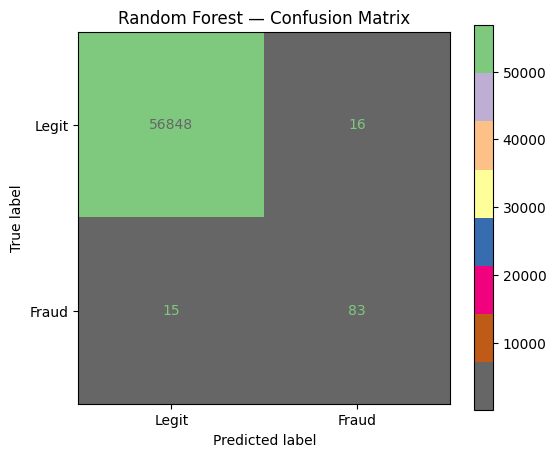

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig,ax=plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(
    rf,
    x_test,
    y_test,
    display_labels=['Legit', 'Fraud'],
    cmap='Accent_r',
    ax=ax
)

plt.title('Random Forest — Confusion Matrix')
plt.show()

#ROC CURVE

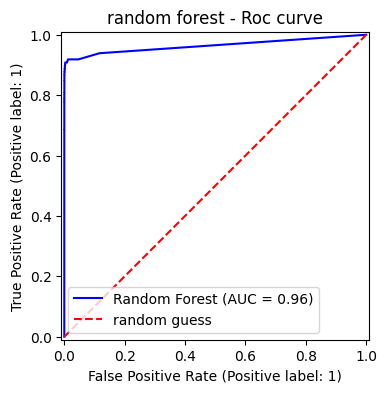

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig,ax=plt.subplots(figsize=(6,4))

RocCurveDisplay.from_estimator(rf,x_test,y_test,name='Random Forest',color='blue',ax=ax)

plt.plot([0,1],[0,1],color='red',linestyle='--',label='random guess')

plt.title('random forest - Roc curve')
plt.legend()
plt.show()

#TOP 10 IMPORTANT FEATURES

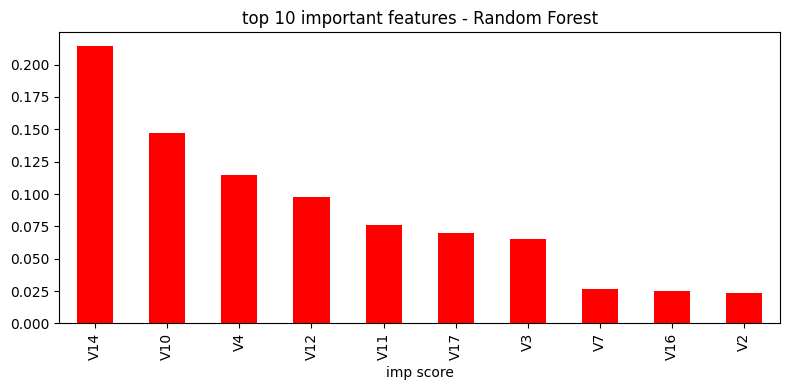

top 10 features
V14    0.2142
V10    0.1473
V4     0.1149
V12    0.0975
V11    0.0762
V17    0.0696
V3     0.0649
V7     0.0267
V16    0.0249
V2     0.0232
dtype: float64


In [ ]:
imp_features=pd.Series(rf.feature_importances_,index=x.columns)

plt.figure(figsize=(8,4))
imp_features.nlargest(10).plot(kind='bar',color='red')
plt.title('top 10 important features - Random Forest')
plt.xlabel('imp score')
plt.tight_layout()
plt.show()

print('top 10 features')
print(imp_features.nlargest(10).round(4))

#THRESHOLD TUNING

In [ ]:
from sklearn.metrics import precision_recall_curve

y_proba_rf = rf.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

optimal_idx = np.argmin(np.abs(precisions[:-1] - recalls[:-1]))
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", round(optimal_threshold, 4))
print("Precision at optimal:", round(precisions[optimal_idx], 4))
print("Recall at optimal:   ", round(recalls[optimal_idx], 4))

Optimal Threshold: 0.52
Precision at optimal: 0.8367
Recall at optimal:    0.8367


#CROSS VALIDATION

In [ ]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

f1_scores=cross_val_score(rf,x,y,cv=cv,scoring='f1')

roc_scores=cross_val_score(rf,x,y,cv=cv,scoring='roc_auc')

print('F1 score per fold:  ', f1_scores.round(3))
print('mean f1 score:  ', round(f1_scores.mean(), 3))
print('std f1 score:  ', round(f1_scores.std(), 3))

print('roc-auc scores per kold: ', roc_scores.round(3))
print('mean roc-auc: ', round(roc_scores.mean(), 3))
print('std roc-auc: ', round(roc_scores.std(), 3))

F1 score per fold:   [0.837 0.875 0.867 0.854 0.842]
mean f1 score:   0.855
std f1 score:   0.014
roc-auc scores per kold:  [0.928 0.969 0.958 0.958 0.937]
mean roc-auc:  0.95
std roc-auc:  0.015


#FINDING BEST PARAMETERS

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_tuned,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train_smote, y_train_smote)

print("=" * 50)
print("BEST PARAMETERS FOUND:")
print("=" * 50)
print(search.best_params_)
print("\nBest F1 Score:", round(search.best_score_, 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
BEST PARAMETERS FOUND:
{'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}

Best F1 Score: 0.9999


#MODEL WITH TUNNED PARAMETERS

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_best=RandomForestClassifier(
    n_estimators=50,
    min_samples_split=5,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(x_train_smote,y_train_smote)
y_pred=rf_best.predict(x_test)

print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)
print(classification_report(y_test,y_pred))
print("ROC-AUC:",round(roc_auc_score(y_test,y_pred), 4))

FINAL MODEL RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9182
